In [1]:
import pandas as pd
import matplotlib.pyplot as plt

 Dữ liệu

In [2]:

df = pd.read_csv('c:/Users/Admin/Downloads/Cleaned_Global_Cybersecurity_Threats_2015-2024.csv')

print(df.head())


   Country  Year        Attack Type     Target Industry  \
0    China  2019           Phishing           Education   
1    China  2019         Ransomware              Retail   
2    India  2017  Man-In-The-Middle                  It   
3       Uk  2024         Ransomware  Telecommunications   
4  Germany  2018  Man-In-The-Middle                  It   

   Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                          80.53                  773169.0  Hacker Group   
1                          62.19                  295961.0       Unknown   
2                          38.65                  605895.0  Hacker Group   
3                          41.44                  659320.0  Nation-State   
4                          74.41                  810682.0       Insider   

  Security Vulnerability Type Defense Mechanism Used  \
0          Unpatched Software                    Vpn   
1          Unpatched Software               Firewall   
2              Weak 

In [3]:
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [4]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.656667,50.599913,504967.895000,36.269333
std,2.839744,28.530633,287712.961446,20.027776
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,26.290000,259510.000000,20.000000
50%,2020.000000,50.990000,505132.500000,36.000000
75%,2022.000000,75.235000,755289.750000,54.000000
max,2024.000000,99.990000,999635.000000,72.000000


Đồ thị 

In [5]:
plt.rcParams['font.family'] = 'Georgia'

Thiệt hại từ cybersecurity 

In [6]:
print("Tổng thiệt hại:", df['Financial Loss (in Million $)'].sum(), )
print("Số người dùng bị ảnh hưởng:", df['Number of Affected Users'].sum(),)



Tổng thiệt hại: 151799.74
Số người dùng bị ảnh hưởng: 1514903685.0


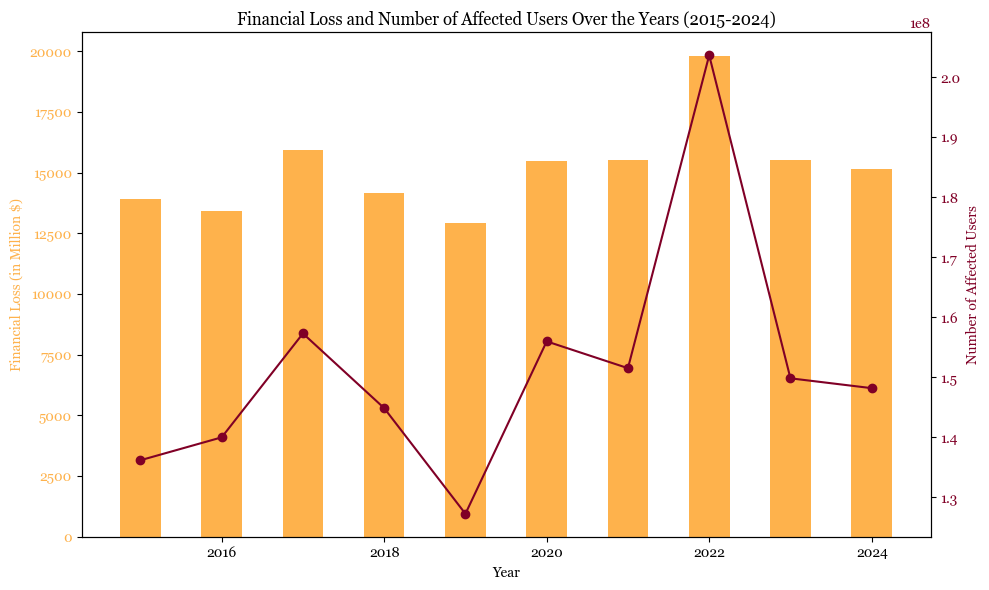

In [7]:

plt.rcParams['font.family'] = 'Georgia'

grouped_data = df.groupby('Year')[['Financial Loss (in Million $)', 'Number of Affected Users']].sum()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(grouped_data.index, grouped_data['Financial Loss (in Million $)'], color='#feb24c', label='Financial Loss (in Million $)', width=0.5)
ax1.set_xlabel('Year')
ax1.set_ylabel('Financial Loss (in Million $)', color='#feb24c')
ax1.tick_params(axis='y', labelcolor='#feb24c')

ax2 = ax1.twinx()
ax2.plot(grouped_data.index, grouped_data['Number of Affected Users'], color='#800026', label='Number of Affected Users', marker='o')
ax2.set_ylabel('Number of Affected Users', color='#800026')
ax2.tick_params(axis='y', labelcolor='#800026')


plt.title('Financial Loss and Number of Affected Users Over the Years (2015-2024)')
fig.tight_layout()
plt.show()


Thiệt hại phân theo ngành 

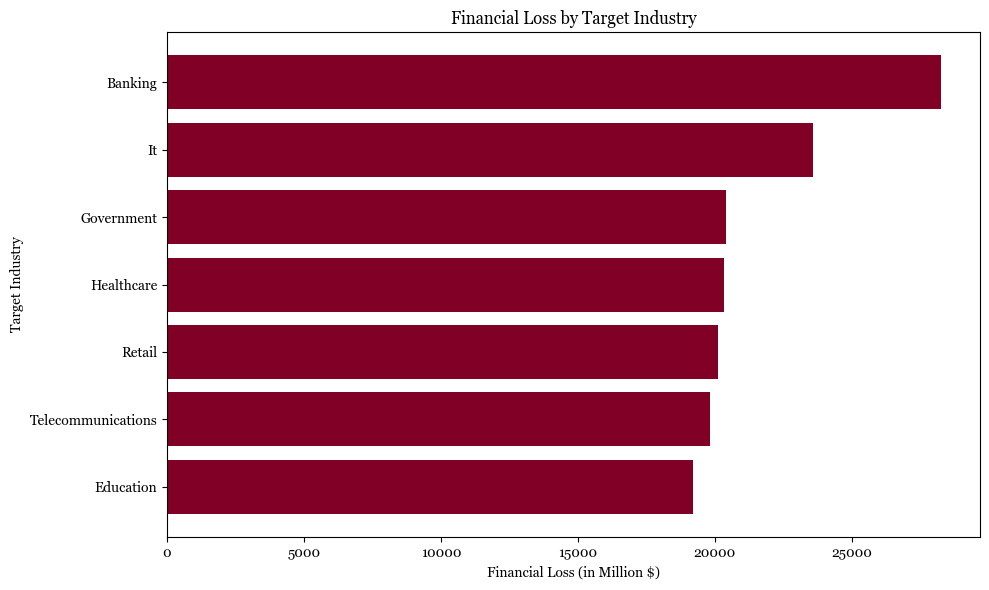

In [8]:
industry_loss = df.groupby('Target Industry')['Financial Loss (in Million $)'].sum().reset_index()

industry_loss = industry_loss.sort_values(by='Financial Loss (in Million $)', ascending=False)

max_loss_index = industry_loss['Financial Loss (in Million $)'].idxmax()

colors = ['#800026']

plt.figure(figsize=(10, 6))
plt.barh(industry_loss['Target Industry'], industry_loss['Financial Loss (in Million $)'], color=colors)
plt.xlabel('Financial Loss (in Million $)')
plt.ylabel('Target Industry')
plt.title('Financial Loss by Target Industry')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


Hình thức tấn công 

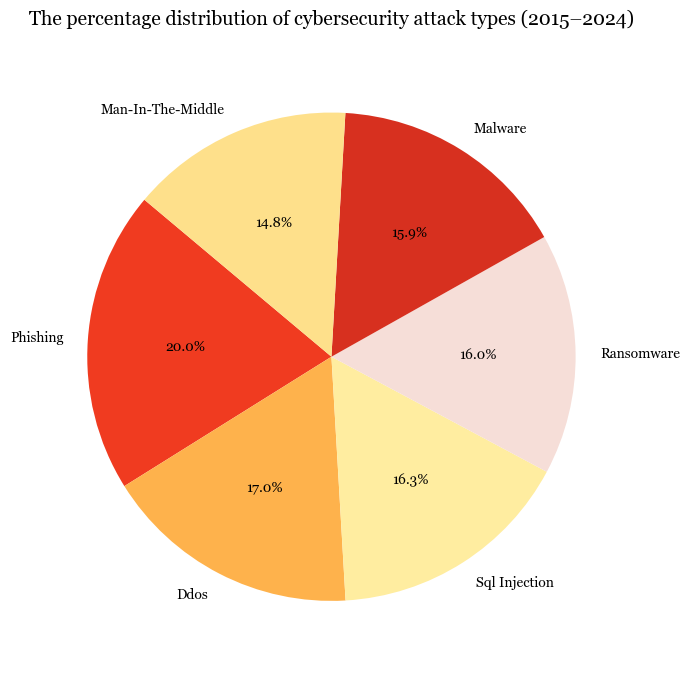

In [9]:
attack_counts = df['Attack Type'].value_counts()

colors=['#f03b20', '#feb24c', '#ffeda0', '#F6DED8', '#d7301f','#fee08b']
plt.figure(figsize=(7, 7))
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%', startangle=140, colors = colors)
plt.title('The percentage distribution of cybersecurity attack types (2015–2024)', fontsize=14)
plt.axis('equal')  
plt.tight_layout()
plt.show()
